In [20]:
# 데이터 시각화
# 데이터 시각화를 위해선 우선 데이터의 종류를 먼저 이해하는 것이 중요

# 1. 수치형 데이타 => 사칙연산 가능
#  - 연속형 실수형태 (키, 몸무게)
#  - 이산형 정수형태 (A반 학생수 , 인원수)

# 2. 범주형 데이터 => 사칙연산 불가
#  - 순서형  순서있음    학점, 설문조사 점수
#  - 명목형  순서없음    성별, 우편번호

# 명목형 → 막대그래프, 파이차트, Countplot
# 순서형 → 정렬된 막대그래프
# 수치형 → 히스토그램, 박스플롯

# ===================================================

# 막대 → 선 → 히스토그램 → 박스플롯 → 산점도 → 히트맵 순서로 이해

# 실무에서 가장 많이 쓰는 TOP 10
# 막대그래프 → 비교
# 선그래프 → 추세
# 산점도 → 관계
# 히스토그램 → 분포(구간별 단변량)
# 박스플롯 → 이상치
# 히트맵 → 상관관계
# 누적막대 → 구성비
# 파이차트 → 비율
# 트리맵 → 계층
# 산점도 + 회귀선 → 예측

# 한 줄 규칙

# 비교 → 막대 (범주(카테고리)끼리 크기를 비교)
# 변화 → 선
# 관계 → 산점도
# 분포 → 히스토그램
# 비율 → 파이
# 상관 → 히트맵

# 자주 쓰는 plt
# | 코드              | 의미    |
# | --------------- | ----- |
# | `plt.figure()`  | 그림 생성 |
# | `plt.plot()`    | 선그래프  |
# | `plt.bar()`     | 막대그래프 |
# | `plt.scatter()` | 산점도   |
# | `plt.hist()`    | 히스토그램 |
# | `plt.pie()`     | 파이차트  |
# | `plt.title()`   | 제목    |
# | `plt.xlabel()`  | x축    |
# | `plt.ylabel()`  | y축    |
# | `plt.grid()`    | 격자    |
# | `plt.show()`    | 출력    |

In [21]:
import os

if not os.path.exists("/content/NanumGothic.ttf"):
    !wget -O /content/NanumGothic.ttf \
    https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 등록
font_path = "/content/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(
    fname=font_path
).get_name()

plt.rc("font", family=font_name)

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# warning 안나오게
import warnings

warnings.filterwarnings("ignore")

In [23]:
# 1. Seaborn은 Python의 데이터 시각화 라이브러리로, 
#  matplotlib을 기반으로 하고 있지만, 더 직관적이고 고급스러운 그래프를 그릴 수 있도록 도와주는 도구
# 2. 통계적 시각화에 특화
# 3. Seaborn은 pandas DataFrame과의 통합이 매우 잘 되어 있어서, pandas에서 직접 데이터를 처리한 뒤 Seaborn으로 바로 시각화
# 4. Seaborn은 기본적으로 아름다운 색상 팔레트와 디자인을 제공


# 수치형 1개
# - 히스토그램   sns.histplot() ,plt.hist() 
# - 분포도 sns.diplot()
# - 박스플롯 sns.boxplot()

# 수치형 2개 이상(변수 관계 확인)
# - 히트맵 sns.heatmap() = 변수관 상관계수 확인
# - 라인플롯 sns.linplot()
# - 산점도 sns.scatterplot()
# - 페어프롯 sns.pairplot()

# 범주형 

# 범주형 1개
# - 카운트 플롯 sns.countplot() => 히스토그램

# 범주형 2개 이상(변수 관계 확인)
# - 막대그래프  sns.barplot()
# - 포인트플롯  sns.pointplot()
# - 박스플롯    sns.boxplot()
# - 바이올린 플롯 sns.violinplot()

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# plt, sns, 히스토리 반영 이거 뭔지 확인하기 

# 시각화를 통한 EDA(탐색적 분석)

df_tips = sns.load_dataset("tips")

df_tips.info()

#분석 = 인사이트 도출 
# 1. tips 데이타는 7 개의 컬럼으로 이루어져 있다.
# 2. 3개의 수치형 데이터 와 4개의 범주형 데이터 
# 3. 결측치는 없으며, 244개의 행으로 이루어져 있다.

print(df_tips.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
    total_bill   tip     sex smoker  day    time  size
0        16.99  1.01  Female     No  Sun  Dinner     2
1        10.34  1.66    Male     No  Sun  Dinner     3
2        21.01  3.50    Male     No  Sun  Dinner     3
3        23.68  3.31    Male     No  Sun  Dinner     2
4        24.59  3.61  Female     No  Sun  Dinner     4
5        25.29  4.71    Male     No  Sun  Dinner     4
6         8.77  2.00    Male     No  Sun  Dinner     2
7        26.88 

In [25]:
df_tips.to_excel("tips_all.xlsx",index=False)

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

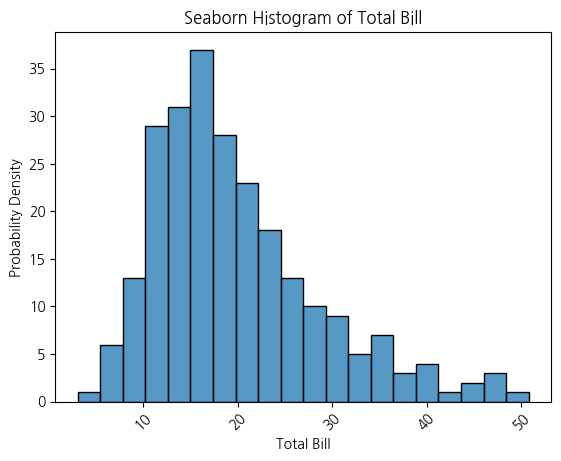

In [26]:
# 분석상 total_bill 과 tips 가 가장 중요한 컬럼으로 인식됨
# tips["total_bill"] 히스토그램을 Seaborn으로 그리기

# ***** ********** 중요 ****************
sns.histplot(data=df_tips,x="total_bill",bins=20)

plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.title("Seaborn Histogram of Total Bill")
plt.xticks(rotation=45)




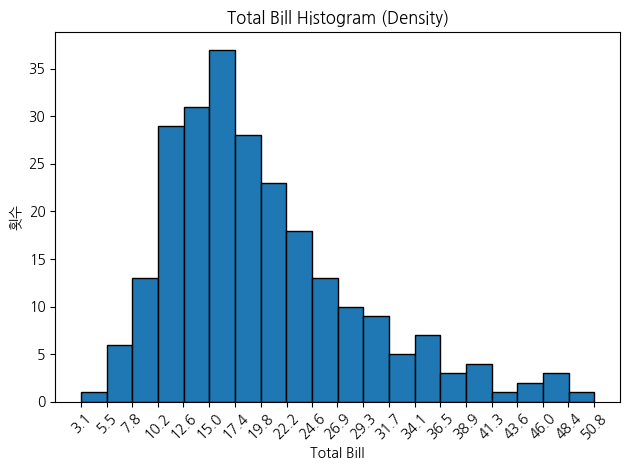

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
tips = sns.load_dataset("tips")

# 히스토그램 정보
bins = 20
counts, bin_edges, _ = plt.hist(
    tips["total_bill"],
    bins=bins,
    density=False,  # 확률 밀도
    edgecolor='black'
)

# x축 눈금 수동 지정: bin 경계값들을 x축 눈금으로 설정
plt.xticks(np.round(bin_edges, 1), rotation=45)  # 필요하면 회전

plt.xlabel("Total Bill")
plt.ylabel("횟수")
plt.title("Total Bill Histogram (Density)")
plt.tight_layout()
plt.show()

In [28]:
# 수치로 확인
df_tips['total_bill'].describe()

# 분석 인사이트 도출
# total_bill 최대 50.810000 최소 3.07 평균 19.78 임을 확인할 수 있다.
# 평균과 중앙값의 차이가 2달러 정도 차이가 난다.

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


<Axes: ylabel='total_bill'>

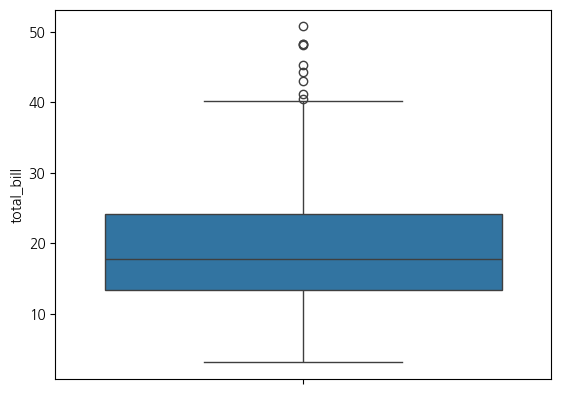

In [ ]:
# 박스플롯
# 박스플롯(Boxplot)
# 전체 분포 현황을 직관적으로 보여준다면,
# boxplot은 박스와 수염 모양으로 여러 가지 정보를 알려준다. (최솟값, 최댓값, Q1, Q2(중위수), Q3 값)
# 형태는 sns.boxplot(x or y, data)
# 데이터의 중심적인 분포를 파악하고, 이상치를 안정적으로 탐지

# 박스의 길이 = Q1 ~ Q3 구간 = IQR(Interquartile Range)
# Q1 = 하위 25%
# Q3 = 상위 75%
# 가운데 50% 데이터가 얼머나 퍼져있는지 보여줌
# 박스가 짧다 => 데이터가 모여있음

# 데이터 변동성이 작음
# 값들이 평균/중앙값 주변에 몰려 있음
# 안정적

# 박 스플롯×을 쉽게 설명하면 박스의 길이는 IQR, 박스가 넓으면 분산이 크다는 의미, 좁으면 중앙값에 값들이 대체적으로 모여있다는 의미
# 박스 플롯의 박스가 작으면 안정적

sns.boxplot(tips["total_bill"])


# ▶ 이상치 판단 기준 (통계적으로)
# 상한 (upper bound): Q3 + 1.5  IQR  
# 하한 (lower bound): Q1 - 1.5 × IQR
# IQR=Q3−Q1  #데이터 집합에서 제3사분위수(Q3)와 제1사분위수(Q1) 간의 차이
# 요소    설명
# Q1 (제1사분위수)    하위 25% 지점의 값
# Q2 (중앙값 / Median)    50% 지점의 값, 상자의 중앙 선
# Q3 (제3사분위수)    상위 25% 지점의 값
# IQR (Interquartile Range)    Q3 - Q1
# 이상치 (Outliers)    상한을 넘거나 하한보다 작은 값 (점으로 표시됨)

# 분석
# 이상치가 보이며 중앙값과 평균 값 20 달러 정도의 차이가 해당 이상치가 원인인 것으로 보임
# 평균하고 중앙값을 따지면 20달러인데 이상치 40달러 이상들은 20달러에 영향을 줄 수 있기 때문에 분포상에서는 이상치라고 함

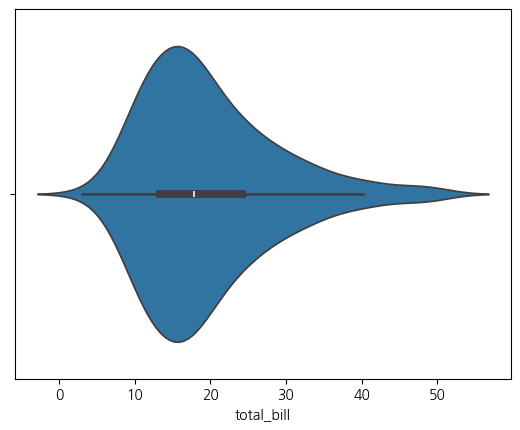

In [30]:
# 바이올린 플롯
# boxplot 분포는 확인하기 좋음
# 분산이 어떤지 확인하기 어려움

# 분산을 확인하기 위한 것이 바이올린 그래프임
# sns.violinplot(x="time",y="total_bill",data=df_tips)

sns.violinplot(data=tips, x='total_bill')
plt.show()

# 뽀족할수록 더 많이 모여있음

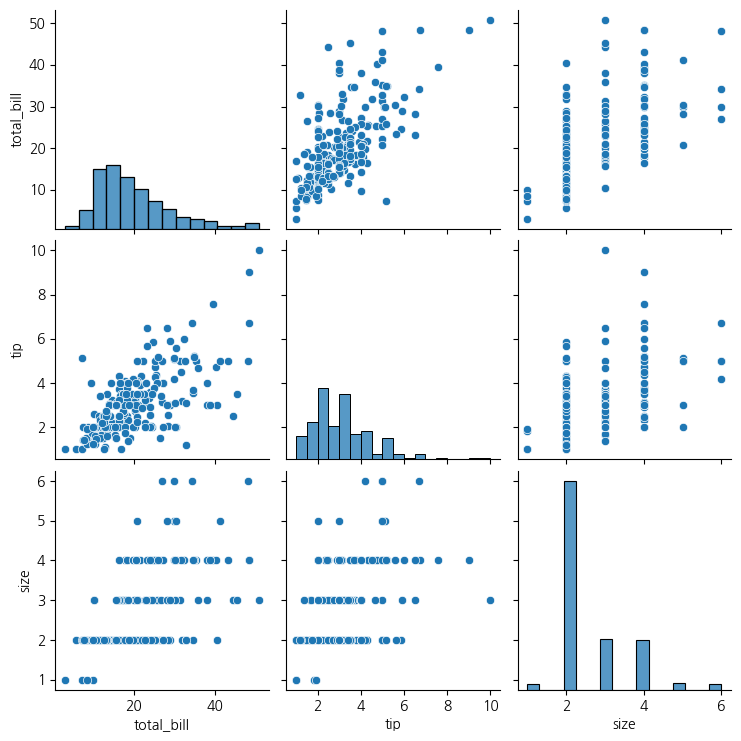

In [ ]:
# 페어 플롯

# seaborn 간판 가장 강력한 기능

# 데이터 수치형 변수들의 쌍별 관계를 한눈데 보여주는 시각화 기능
# 자기가 알아서 이산형(size), 연속형(total_bill,tips) 구분해서 히스토그램 및 산점도 각각에 대응해서 그려줌
# 산점도와 히스토그램 그래프를  각 변수 간의 모든 가능한 조합을 2차원 그래프로 그려줌

sns.pairplot(df_tips)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


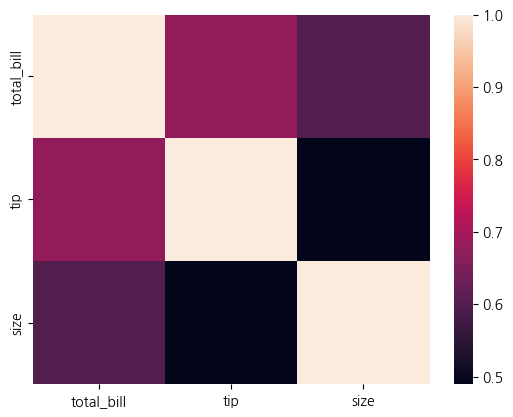

In [ ]:
# ⁠3. 수치형 변수 2개 이상 시각화(변수 간 관계 확인)

#히트맵: sns.heatmap()
#라인플롯: sns.lineplot()
#산점도: sns.scatterplot()
#회귀선 + 산점도: sns.regplot()

# ⁠1) 히트맵(heatmap)
#보통 히트맵은 수치형 변수들 간의 상관관계를 나타낼 때 자주 사용한다.

#tips 데이터셋의 상관계수를 구해보자. corr() 함수를 사용한다.
#히트맵 예전버전과 에러
#https://twdatastory.tistory.com/entry/tipscorr-ValueError-could-not-convert-string-to-float-No

#피어슨 상관관계 설명
#https://dd0za-1004.tistory.com/46

#공분산의 이해
#https://ds92.tistory.com/124


tip_corr = tips.corr(numeric_only=True) # 피어슨 상관계수
print(tip_corr)

sns.heatmap(tip_corr)
plt.show()

# 분석
# 팁과 전체 금액과는 상관관계가 있으며, size 와는 관계는 있으나 약해 보임
# 절댓값이 1에 가까운 상관계수: 매우 확고한 상관.

# EDA (탐색적 데이터 분석) 할 시 전처리를 먼저하고 EDA 내에서 먼저 단변량 분석, 다변량 분석 순으로 진행

<Axes: xlabel='size', ylabel='tip'>

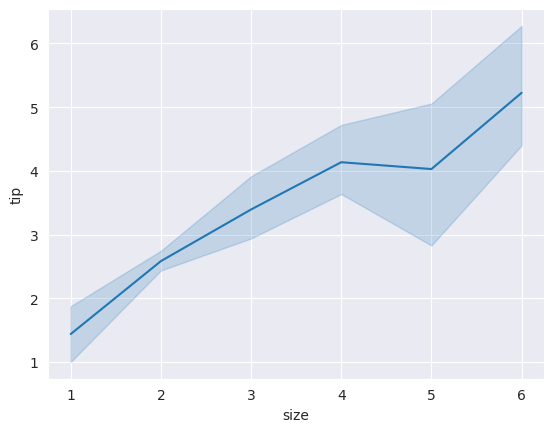

In [ ]:
#라인 플롯
#라인플롯은 두 수치형 데이터 사이의 관계를 선으로 나타낸다.
#주로 x축에는 이산형(discrete) 데이터, y축에는 연속형(continuous) 데이터를 쓸 때 사용한다.
#그 이유는 x값에 따른 y값의 평균값을 선으로 이어주기 때문이다.
#형태는 sns.lineplot(x, y, hue(범주형), data)

#스타일 설정
#style : 'white', 'dark', 'whitegrid', 'darkgrid' - 테마들을 설정할 수 있음
sns.set_style("darkgrid")

# 두 수치형 데이터 size, tip 간 관계를 시각화
sns.lineplot(x='size',y='tip',data=df_tips)

# 참고로 그림자가 넓다 = 데이터가 많이 흔들린다(분산 큼),
# 그림자가 좁다 = 데이터가 안정적이다(분산 작음) 라고 해석하는 경우가 많음
# 라인은 기본적으로 평균임

# 분석
# 1. 인원수가 증가할수록 팁도 증가하는 경향이 있음
# 2. 변동성이나 이상값도 해당 그래프에서 그림자로 확인 가능
# 그림자(shaded area) 는 보통 신뢰구간(Confidence Interval, CI) 또는 오차 범위

<Axes: xlabel='total_bill', ylabel='tip'>

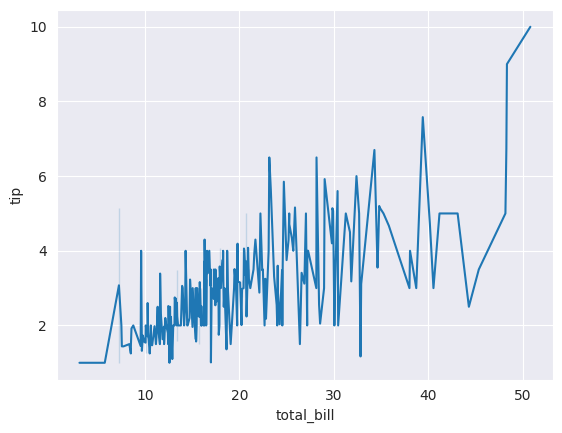

In [ ]:
# x,y 둘다 연속형을 쓰면? 이상해짐

sns.lineplot(x='total_bill',y='tip',data=df_tips)

# 분석
# 라인플롯에서 연속형 데이터를 둘다 x,y 축으로 쓰면 안됨(이상해짐)
# x 축에는 대체적으로 연속형이 아닌 범주형, 이산형데이터가 들어가는게 좋음

<Axes: xlabel='total_bill', ylabel='tip'>

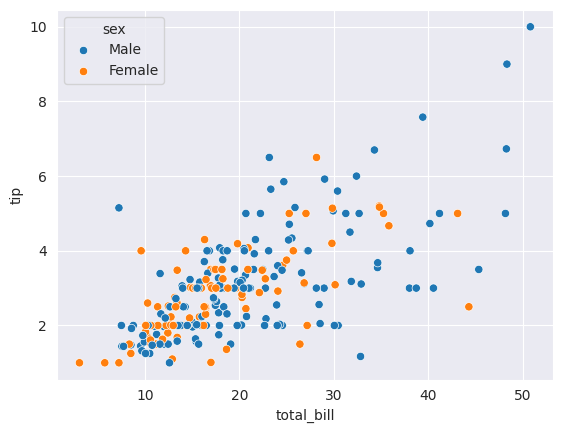

In [ ]:
# 산점도

# 주로 x, y축에 모두 연속형 데이터를 넣을 때 자주 사용한다.
# 형태는 sns.scatterplot(x, y, hue(범주형), data)

sns.scatterplot(x="total_bill",y="tip",data=df_tips,hue="sex")

# 분석
# 1. 총 금액이 많아질수록 팁도 많아지는 경향이 있음
# 2. 성별에 따른 팁은 차이를 구분할 수 없음
# 3. 이상치도 그래프로 확인 가능 => 저정도로 성별에 따른 팁에 차이가 있다고 볼 수 없음

<Axes: xlabel='size', ylabel='tip'>

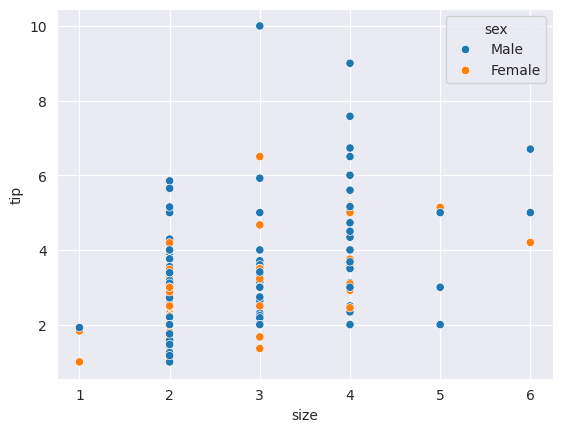

In [ ]:
sns.scatterplot(x="size",y="tip",data=df_tips,hue="sex")

# 분석
# 1. 산점도에서 x축에 범주형 변수도 분석이 가능
# 2. size3의 팁이 10은 확실히 이상치로 보임 (여기에서의 해석은 팁은 가끔 기대 이상으로 받을 때도 있다라고 해석)
# 3. 식사 인원이 많을수록 평균적인 팁 금액이 증가하는 경향은 있으나, 5,6인은 데이터 부족으로 인하여, 인원수가 커도 팁이 꼭 많지는 않다는 것을 확인
# 4. 범주형이 x축에 있으면, 이상치 확인이 용이

<Axes: xlabel='day', ylabel='count'>

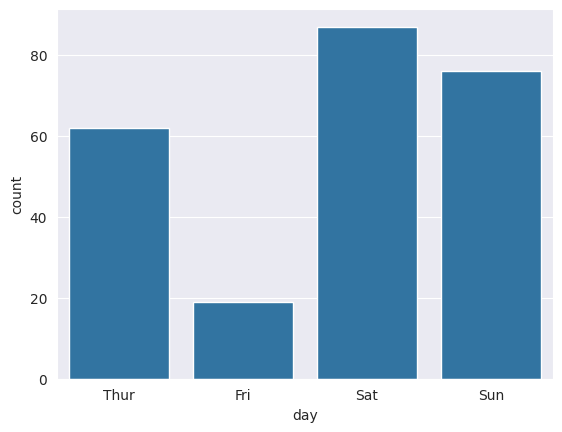

In [ ]:
# 범주형 데이터 
# 아래 몇개의 그래프는 단변량 그래프

sns.countplot(x="day",data=df_tips)

# 분석
# 1. 범주형 데이터는 변수 1개 짜리는 countplot으로 분석할 수 있음 (plt.bar)
# 2. 주말에 평일보다 손님이 많은 것을 확인 가능

<Axes: xlabel='smoker', ylabel='count'>

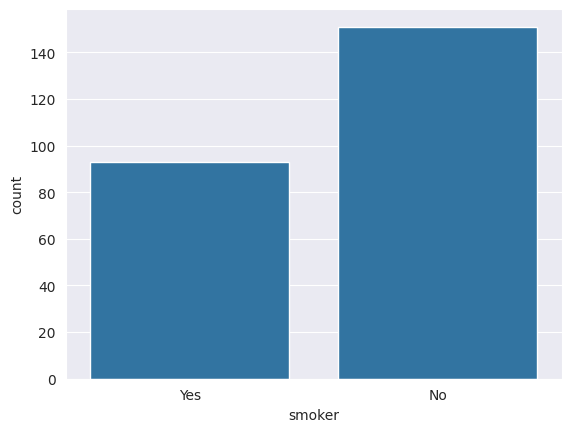

In [ ]:
sns.countplot(x="smoker",data=df_tips)

# 분석
# 비 흡연자가 더 많이 방문


<Axes: xlabel='sex', ylabel='count'>

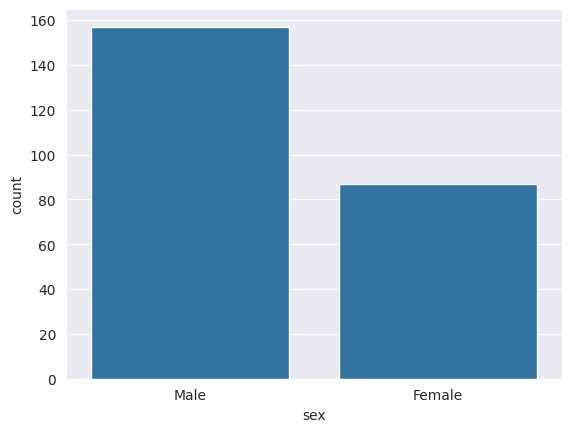

In [ ]:
sns.countplot(x="sex",data=df_tips)

# 분석
# 남성이 여성보다 더 많이 방문

<Axes: xlabel='time', ylabel='count'>

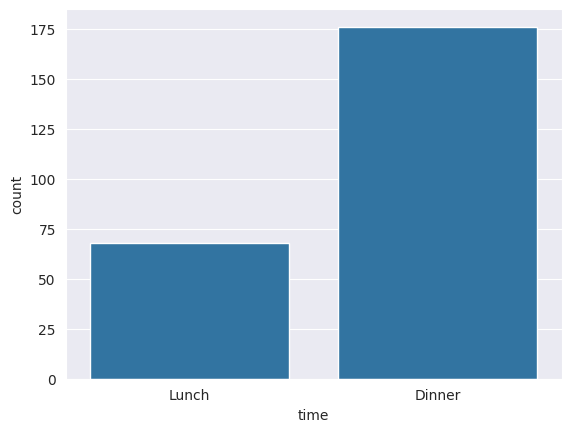

In [ ]:
sns.countplot(x="time",data=df_tips)

# 분석
# 저녁 시간에 점심보다 2배 이상 방문 

<Axes: xlabel='sex', ylabel='tip'>

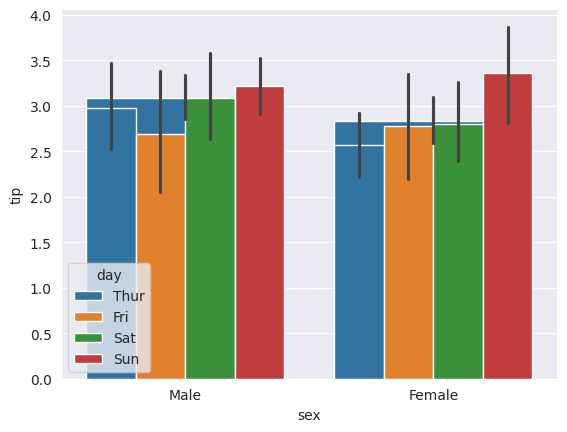

In [ ]:
# 범주형 그래프 - x,y 처리 그래프

# 막대 그래프
sns.barplot(x="sex",y="tip",data=df_tips)

# 그래프의 검은 세로선은 해당 평균의 95% 신뢰구간
# male의 팁 평균이 3.0이고, 검은선이 2.5~3.5라면 : 실제 평균 팁이 이 범위 안에 있을 확률이 95%다" 라는 통계적 의미

sns.barplot(x="sex",y="tip",data=df_tips,hue="day")
# hue는 groupby와 같은 의미, day를 기준으로 그래프를 그리라는 뜻

<Axes: xlabel='day', ylabel='tip'>

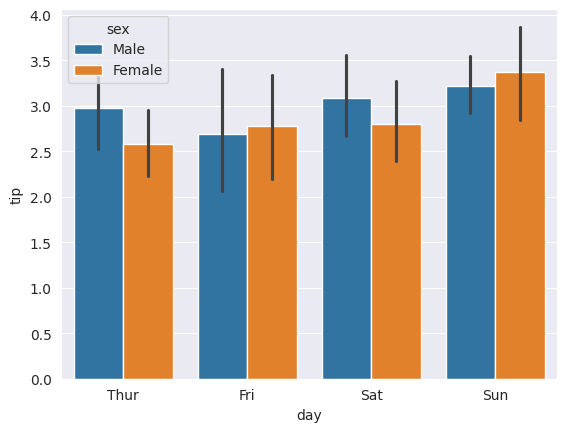

In [ ]:
# 요일별 tip 평균
sns.barplot(x="day",y="tip",data=df_tips,hue="sex")

# 분석
# 주말일수록 팁을 더 내는 경향이 있음

<Axes: xlabel='time', ylabel='total_bill'>

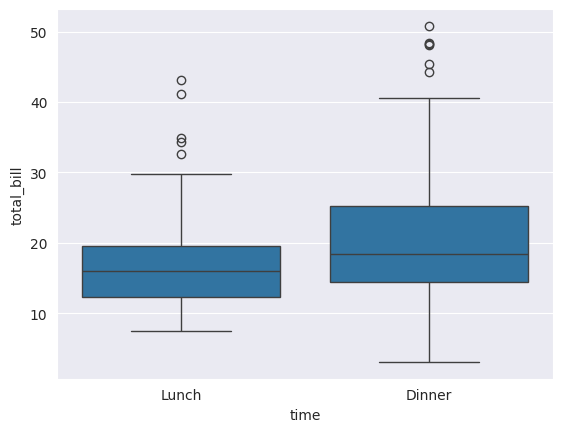

In [53]:
# 박스 플롯
sns.boxplot(x="time",y="total_bill",data=df_tips)

# 분석
# 1. 저녁이 점심보다 돈을 더 많이 씀
# 2. 점심응ㄴ 상대적으로 변동성이 작고 중앙값도 낮다 => 점심은 간단히, 저녁은 다양하고 고가로 먹는 경향이 있음
# 3. 점심 데이터는 중앙값 근처에 몰린 데이터가 많음

# 결론
# 점심은 간단히 저녁은 다양하고 고가로


<Axes: xlabel='total_bill', ylabel='time'>

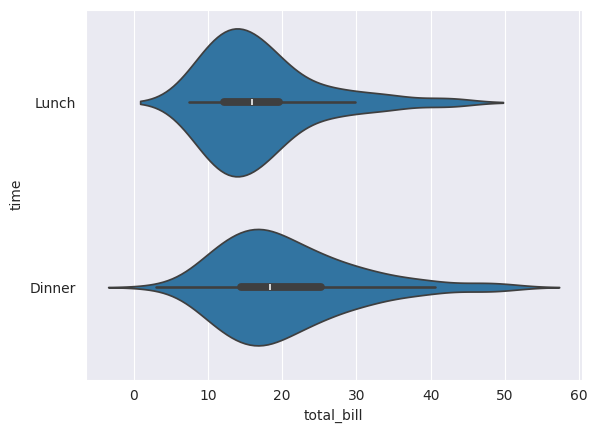

In [52]:
# 바이올린 플롯

# boxplot 분포는 확인 하기 좋음
# 분산이 어떤지 확인 하기 어려움
#분산을 확인 하기 위한게, 바이올린 그래프임
#sns.violinplot(x="time", y="total_bill",data=df_tips)

#분석
# 1.저녁시간의 식사 금액이 전반적으로 크고 다양하다.
# 2.점심은 대체로 저렴하고 균일한 금액이 분포한다.
# 3.저녁식사에 고가 식사가 존재 할수도 있다

#결론
#가장 중위수가 몰린 것은 점심 때임(가운데 쪽으로 볼록 하게 튀어 나왔으므로)

sns.violinplot(x="total_bill", y="time",data=df_tips)

In [ ]:
# 남성과 여성의 평균 결제 금약은 차이가 있는가?
# 요일별 평균 식사금액 차이?
# 식사금액과 팁은 관련이 있는가? (많이 먹으면 팁을 많이 주는가)